<a href="https://colab.research.google.com/github/JeswanthReddy78/DSCI-2025-TEAM-F/blob/main/Classification%26clustering_Graph_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the uploaded datasets
superfund_features_df = pd.read_csv("/content/DATA001_superfund_feature_dataframe_v1.csv")
superfund_matrix_df = pd.read_csv("/content/DATA001_superfund_feature_matrix_v1.csv")
superfund_node_map_df = pd.read_csv("/content/DATA001_superfund_node_id_map_v1.csv")

county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_matrix_df = pd.read_csv("/content/DATA002_county_feature_matrix_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")

# Display the first few rows to understand structure
(superfund_features_df.head(), superfund_node_map_df.head(),
 county_features_df.head(), county_node_map_df.head())


(   site_id        lat        lon  fed_facility  native_land  \
 0   100041  41.940561 -71.966939             0            0   
 1   100108  41.481110 -72.681388             0            0   
 2   100121  41.708331 -71.829169             0            0   
 3   100124  41.619600 -72.878000             0            0   
 4   100125  41.669450 -71.964161             0            0   
 
    hazard_rank_score  final_list_days  proposed_days  proposal_gulf  \
 0              33.71            12733          13340            607   
 1              33.94            12873          13340            467   
 2              41.06            13678          14085            407   
 3              44.93            15091          15343            252   
 4              36.72            15091          15343            252   
 
    is_finalized  ...  99-35-4  99-65-0  99-87-6  99-99-0  993-13-5  \
 0             1  ...        0        0        0        0         0   
 1             1  ...        0        

In [3]:
# Rename fips_x to fips for consistency
superfund_with_node_id.rename(columns={"fips_x": "fips"}, inplace=True)

# Now merge on FIPS to create edges
edges_df = pd.merge(
    superfund_with_node_id[["superfund_node_id", "fips"]],
    county_with_node_id[["county_node_id", "fips"]],
    on="fips"
)

# Extract edge list
edge_list = edges_df[["county_node_id", "superfund_node_id"]].values.tolist()

# Display a sample of the edges
edge_list[:5]


[[2320, 14], [2320, 15], [1604, 16], [2009, 17], [1591, 18]]

In [4]:
pip install torch torch-geometric scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [3]:
import pandas as pd
import torch
from torch_geometric.data import Data

# Load your numeric matrices
county_matrix_df = pd.read_csv("/content/DATA002_county_feature_matrix_v1.csv")
superfund_matrix_df = pd.read_csv("/content/DATA001_superfund_feature_matrix_v1.csv")

# Keep only numeric columns
county_numeric = county_matrix_df.select_dtypes(include=['number'])
superfund_numeric = superfund_matrix_df.select_dtypes(include=['number'])

# Convert to tensors
county_tensor = torch.tensor(county_numeric.values, dtype=torch.float)
superfund_tensor = torch.tensor(superfund_numeric.values, dtype=torch.float)

# Pad to equal dimensions
max_dim = max(county_tensor.shape[1], superfund_tensor.shape[1])
def pad(tensor, dim): return torch.cat([tensor, torch.zeros((tensor.size(0), dim - tensor.size(1)))], dim=1)
county_tensor = pad(county_tensor, max_dim)
superfund_tensor = pad(superfund_tensor, max_dim)

# Combine tensors
x = torch.cat([county_tensor, superfund_tensor], dim=0)

# Load node maps and make edge list
county_map = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv").rename(columns={"row_index": "county_node_id"})
superfund_map = pd.read_csv("/content/DATA001_superfund_node_id_map_v1.csv").rename(columns={"row_index": "superfund_node_id", "fips": "fips"})
edges_df = pd.merge(superfund_map[["superfund_node_id", "fips"]], county_map[["county_node_id", "fips"]], on="fips")

# Offset superfund indices
edge_list = [[row["county_node_id"], row["superfund_node_id"] + county_tensor.size(0)] for _, row in edges_df.iterrows()]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# Create graph
data = Data(x=x, edge_index=edge_index)
print(data)


Data(x=[4536, 736], edge_index=[2, 1505])


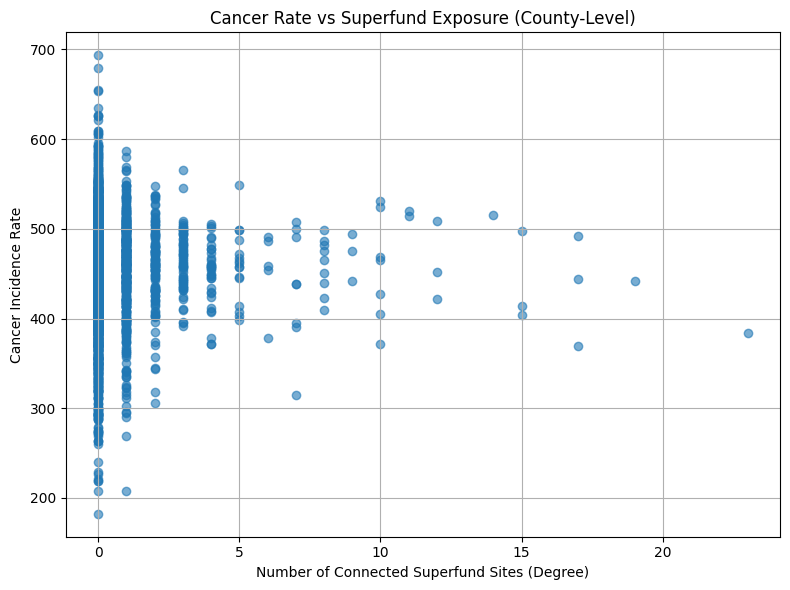

In [4]:
import pandas as pd

# Reload necessary county features for visualization (cancer rate, trends)
county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")

# Merge to bring node index into features
county_data = pd.merge(county_node_map_df.rename(columns={"row_index": "county_node_id"}),
                       county_features_df, on="fips")

# Count number of connections (degree) for each county node
from collections import Counter
degree_count = Counter([edge[0] for edge in edge_list])

# Map degree to county_data
county_data["degree"] = county_data["county_node_id"].map(degree_count).fillna(0).astype(int)

# Show sample of merged data for plotting
import matplotlib.pyplot as plt

# Scatter plot: cancer_rate vs superfund degree exposure
plt.figure(figsize=(8, 6))
plt.scatter(county_data["degree"], county_data["cancer_rate"], alpha=0.6)
plt.xlabel("Number of Connected Superfund Sites (Degree)")
plt.ylabel("Cancer Incidence Rate")
plt.title("Cancer Rate vs Superfund Exposure (County-Level)")
plt.grid(True)
plt.tight_layout()
plt.show()


This scatter plot helps explore any potential correlation between environmental exposure (via proximity to Superfund sites) and cancer rates.

In [49]:
import pandas as pd
import torch
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data
import torch.nn.functional as F
from sklearn.metrics import classification_report

# Load county and superfund data
county_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_map = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv").rename(columns={"row_index": "county_node_id"})
superfund_map = pd.read_csv("/content/DATA001_superfund_node_id_map_v1.csv").rename(columns={"row_index": "superfund_node_id", "fips": "fips"})
county_matrix = pd.read_csv("/content/DATA002_county_feature_matrix_v1.csv").select_dtypes(include=['number'])
superfund_matrix = pd.read_csv("/content/DATA001_superfund_feature_matrix_v1.csv").select_dtypes(include=['number'])

# Convert to tensors and pad
def pad(tensor, dim): return torch.cat([tensor, torch.zeros((tensor.size(0), dim - tensor.size(1)))], dim=1)
county_tensor = torch.tensor(county_matrix.values, dtype=torch.float)
superfund_tensor = torch.tensor(superfund_matrix.values, dtype=torch.float)
max_dim = max(county_tensor.size(1), superfund_tensor.size(1))
county_tensor = pad(county_tensor, max_dim)
superfund_tensor = pad(superfund_tensor, max_dim)
x = torch.cat([county_tensor, superfund_tensor], dim=0)

# Create edge index
edges_df = pd.merge(superfund_map[["superfund_node_id", "fips"]],
                    county_map[["county_node_id", "fips"]], on="fips")
num_county_nodes = county_tensor.size(0)
edges = [[row["county_node_id"], row["superfund_node_id"] + num_county_nodes] for _, row in edges_df.iterrows()]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Prepare multi-class labels (0: falling, 1: stable, 2: rising)
county_map = pd.merge(county_map, county_df[["fips", "trend_falling", "trend_stable", "trend_rising"]], on="fips")
labels = county_map[["trend_falling", "trend_stable", "trend_rising"]].idxmax(axis=1).map({
    "trend_falling": 0,
    "trend_stable": 1,
    "trend_rising": 2
}).values

# Set up PyG data
y = torch.full((x.size(0),), -1, dtype=torch.long)  # initialize with -1 for superfund nodes
y[:num_county_nodes] = torch.tensor(labels, dtype=torch.long)
train_mask = torch.zeros(x.size(0), dtype=torch.bool)
train_mask[:num_county_nodes] = True  # only county nodes are labeled

data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask)

# Define GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphSAGE(x.size(1), 64, 3).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}")

# Evaluation
model.eval()
pred = out.argmax(dim=1)
true = data.y[data.train_mask].cpu().numpy()
predicted = pred[data.train_mask].cpu().numpy()
print("\nClassification Report (County Nodes):")
print(classification_report(true, predicted, target_names=["Falling", "Stable", "Rising"]))


Epoch 010, Loss: 2.1881
Epoch 020, Loss: 0.7231
Epoch 030, Loss: 0.6988
Epoch 040, Loss: 0.6650
Epoch 050, Loss: 0.6300
Epoch 060, Loss: 0.6057
Epoch 070, Loss: 0.5779
Epoch 080, Loss: 0.5608
Epoch 090, Loss: 0.5290
Epoch 100, Loss: 0.5230

Classification Report (County Nodes):
              precision    recall  f1-score   support

     Falling       0.73      0.41      0.53       610
      Stable       0.79      0.96      0.86      2118
      Rising       1.00      0.01      0.02       202

    accuracy                           0.78      2930
   macro avg       0.84      0.46      0.47      2930
weighted avg       0.79      0.78      0.74      2930



**Class Imbalance**

Stable dominates (72% of data)

Rising has only 202 samples (~7%) → the model learns to ignore it to maximize overall accuracy

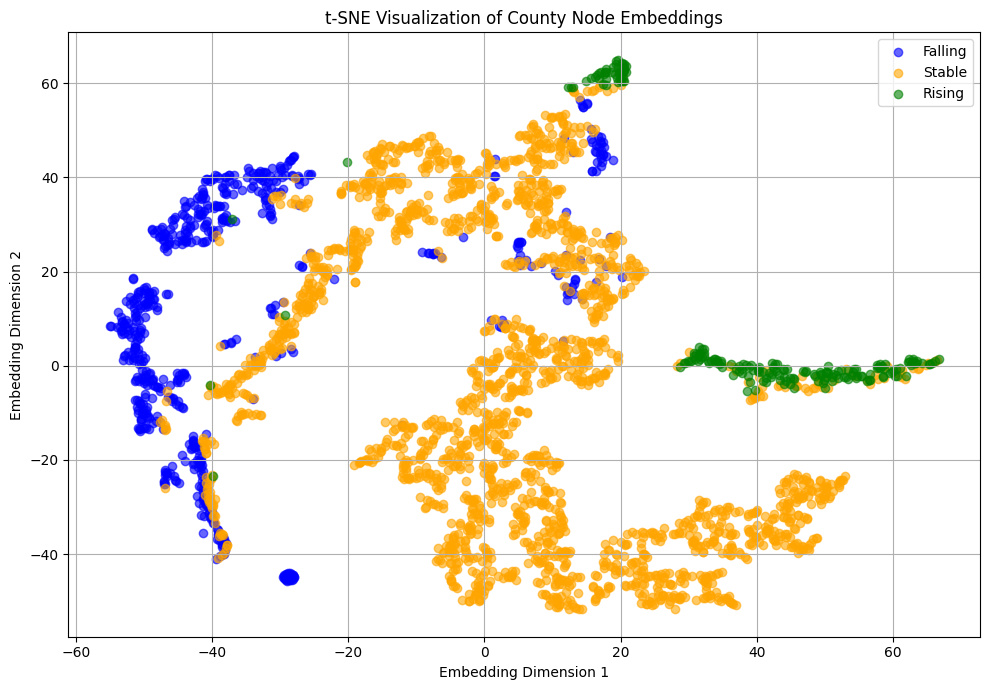

In [50]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get final node embeddings from GraphSAGE
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()

# Extract only county node embeddings
county_embeddings = embeddings[:num_county_nodes]
county_labels = y[:num_county_nodes].cpu().numpy()

# Reduce dimensions to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42)
county_embeddings_2d = tsne.fit_transform(county_embeddings)

# Plot
plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green']
labels_map = {0: 'Falling', 1: 'Stable', 2: 'Rising'}

for class_id in range(3):
    idx = county_labels == class_id
    plt.scatter(county_embeddings_2d[idx, 0], county_embeddings_2d[idx, 1],
                c=colors[class_id], label=labels_map[class_id], alpha=0.6)

plt.title("t-SNE Visualization of County Node Embeddings")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The model clearly separates rising trend counties — indicating it has learned to detect unique features or structural patterns (e.g., exposure or trends).

Stable counties are dominant and span a wide embedding space — possibly because their features vary more but still lead to the same class.

Falling counties are more loosely grouped but still form coherent zones.

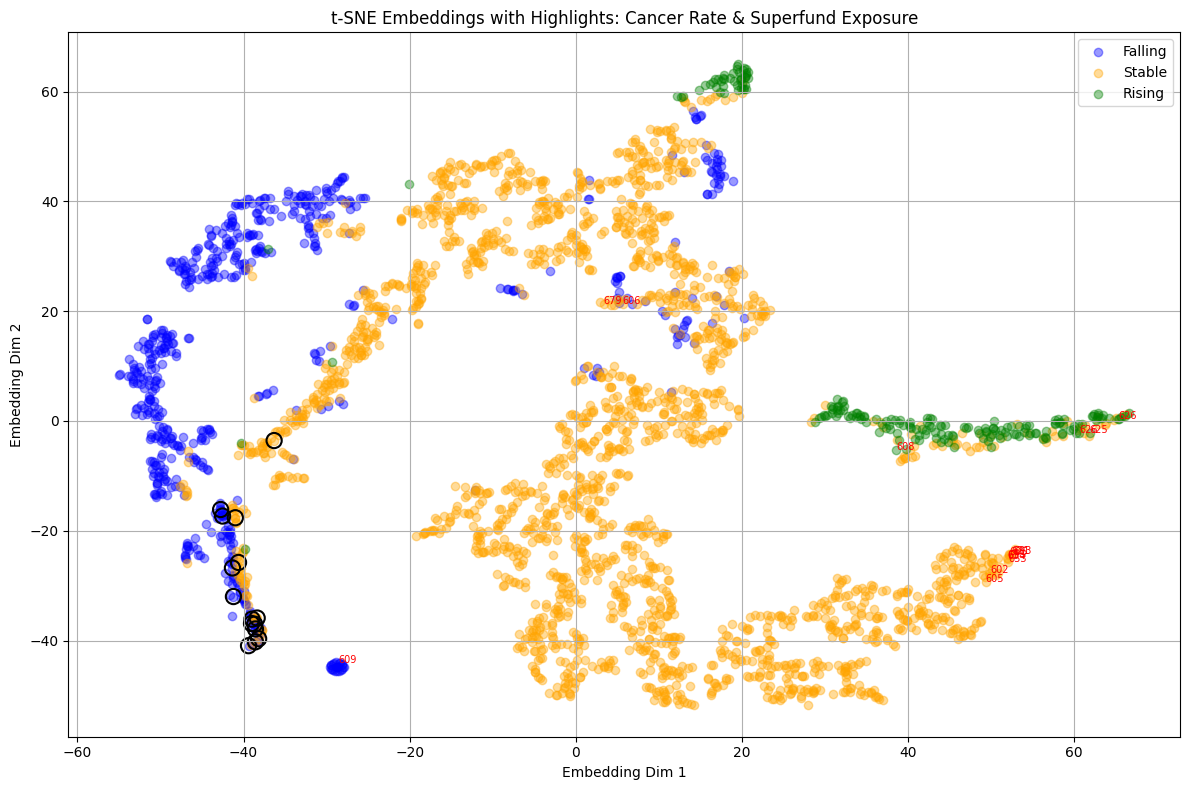

In [51]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reload datasets to get degree and cancer rate
county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")

# Merge node ID into feature set
county_data = pd.merge(county_node_map_df.rename(columns={"row_index": "county_node_id"}),
                       county_features_df, on="fips")

# Count superfund connections per county
from collections import Counter
degree_count = Counter([edge[0] for edge in edge_list])
county_data["degree"] = county_data["county_node_id"].map(degree_count).fillna(0).astype(int)

# Sort by exposure and cancer rate
top_exposed = county_data.sort_values("degree", ascending=False).head(15)
top_cancer = county_data.sort_values("cancer_rate", ascending=False).head(15)

# t-SNE for embedding visualization
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()
county_embeddings = embeddings[:num_county_nodes]
county_labels = data.y[:num_county_nodes].cpu().numpy()
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(county_embeddings)

# Plot with highlights
plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green']
labels_map = {0: 'Falling', 1: 'Stable', 2: 'Rising'}

# Base scatter plot
for class_id in range(3):
    idx = county_labels == class_id
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
                c=colors[class_id], label=labels_map[class_id], alpha=0.4)

# Highlight top exposed counties
for _, row in top_exposed.iterrows():
    nid = row["county_node_id"]
    plt.scatter(embeddings_2d[nid, 0], embeddings_2d[nid, 1],
                edgecolor='black', facecolor='none', s=120, linewidths=1.5, label='Top Exposure' if _ == 0 else "")

# Annotate top cancer rate counties
for _, row in top_cancer.iterrows():
    nid = row["county_node_id"]
    plt.text(embeddings_2d[nid, 0], embeddings_2d[nid, 1],
             f"{int(row['cancer_rate'])}", fontsize=7, color='red')

plt.title("t-SNE Embeddings with Highlights: Cancer Rate & Superfund Exposure")
plt.xlabel("Embedding Dim 1")
plt.ylabel("Embedding Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Top Superfund-Exposed Counties:
These are outlined with black circles.

Top Cancer Rate Counties: These have red number annotations showing their cancer incidence rate.

In [38]:
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import f1_score

# Split county nodes into train/val (e.g., 80/20 split)
from sklearn.model_selection import train_test_split
train_ids, val_ids = train_test_split(range(num_county_nodes), test_size=0.2, stratify=labels, random_state=42)

train_mask = torch.zeros(x.size(0), dtype=torch.bool)
val_mask = torch.zeros(x.size(0), dtype=torch.bool)
train_mask[train_ids] = True
val_mask[val_ids] = True

# Setup data
data.train_mask = train_mask.to(device)
data.val_mask = val_mask.to(device)
data.y = torch.tensor(np.concatenate([labels, [-1] * (x.size(0) - len(labels))]), dtype=torch.long).to(device)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
# Define optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Early stopping parameters
best_f1 = 0
patience = 10
patience_counter = 0
best_model_state = None

# Training loop
for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Evaluation on validation set
    model.eval()
    val_pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
    val_true = data.y[data.val_mask].cpu().numpy()
    macro_f1 = f1_score(val_true, val_pred, average='macro')

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Macro F1: {macro_f1:.4f} | Patience: {patience_counter}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# Restore best model state
model.load_state_dict(best_model_state)

# Final Evaluation
model.eval()
final_pred = out[data.train_mask].argmax(dim=1).cpu().numpy()
final_true = data.y[data.train_mask].cpu().numpy()
print("\nClassification Report (County Nodes):")
print(classification_report(final_true, final_pred, target_names=["Falling", "Stable", "Rising"]))


Epoch 001 | Loss: 1.1833 | Macro F1: 0.3535 | Patience: 0
Epoch 002 | Loss: 1.0009 | Macro F1: 0.3927 | Patience: 0
Epoch 003 | Loss: 1.0459 | Macro F1: 0.2750 | Patience: 1
Epoch 004 | Loss: 1.0293 | Macro F1: 0.2524 | Patience: 2
Epoch 005 | Loss: 1.0119 | Macro F1: 0.3087 | Patience: 3
Epoch 006 | Loss: 1.0042 | Macro F1: 0.3241 | Patience: 4
Epoch 007 | Loss: 0.9815 | Macro F1: 0.3778 | Patience: 5
Epoch 008 | Loss: 0.9935 | Macro F1: 0.3917 | Patience: 6
Epoch 009 | Loss: 0.9796 | Macro F1: 0.3643 | Patience: 7
Epoch 010 | Loss: 0.9605 | Macro F1: 0.3433 | Patience: 8
Epoch 011 | Loss: 0.9481 | Macro F1: 0.4034 | Patience: 0
Epoch 012 | Loss: 0.9463 | Macro F1: 0.4209 | Patience: 0
Epoch 013 | Loss: 0.9529 | Macro F1: 0.4737 | Patience: 0
Epoch 014 | Loss: 0.9169 | Macro F1: 0.4131 | Patience: 1
Epoch 015 | Loss: 0.9343 | Macro F1: 0.3997 | Patience: 2
Epoch 016 | Loss: 0.9298 | Macro F1: 0.4878 | Patience: 0
Epoch 017 | Loss: 0.9110 | Macro F1: 0.5232 | Patience: 0
Epoch 018 | Lo

Used Class weighting, Early stopping, Learning rate tuning


Classification Report (SMOTE + Classifier on Embeddings):
              precision    recall  f1-score   support

     Falling       0.79      0.98      0.88       610
      Stable       0.98      0.83      0.90      2118
      Rising       0.47      0.89      0.62       202

    accuracy                           0.87      2930
   macro avg       0.75      0.90      0.80      2930
weighted avg       0.91      0.87      0.88      2930



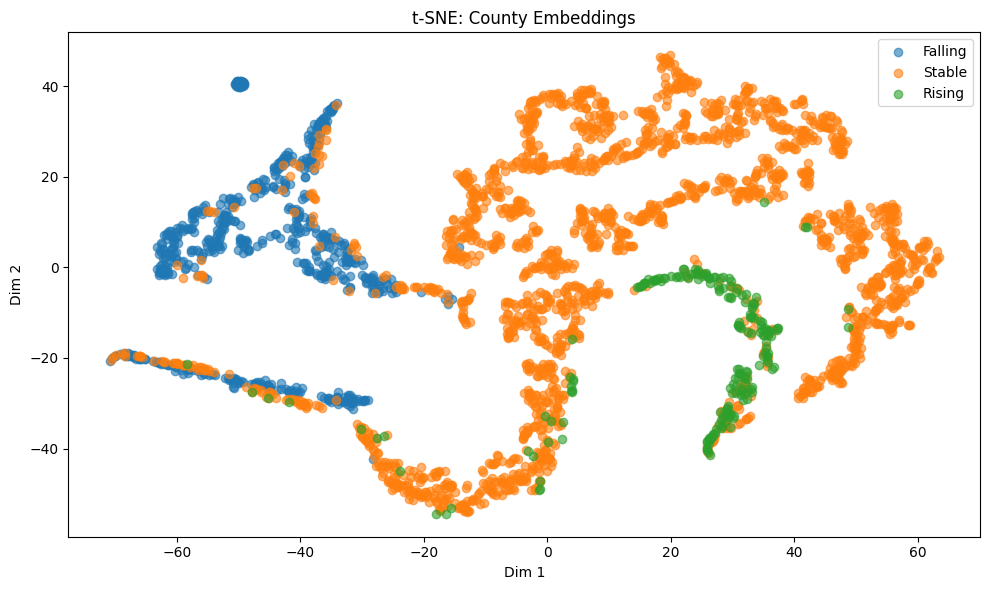

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

#  Get county node embeddings from the trained model
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu().numpy()

#  Filter to county nodes only
county_embeddings = embeddings[:num_county_nodes]
county_labels = data.y[:num_county_nodes].cpu().numpy()

#  Apply SMOTE to balance Rising class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(county_embeddings, county_labels)

#  Train classifier on resampled data
clf = LogisticRegression(max_iter=500)
clf.fit(X_resampled, y_resampled)

#  Predict on original county embeddings
y_pred = clf.predict(county_embeddings)

#  Classification Report
print("\nClassification Report (SMOTE + Classifier on Embeddings):")
print(classification_report(county_labels, y_pred, target_names=["Falling", "Stable", "Rising"]))

#  t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_proj = tsne.fit_transform(county_embeddings)

plt.figure(figsize=(10, 6))
for i, label in enumerate(["Falling", "Stable", "Rising"]):
    plt.scatter(tsne_proj[county_labels == i, 0], tsne_proj[county_labels == i, 1], label=label, alpha=0.6)
plt.legend()
plt.title("t-SNE: County Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()

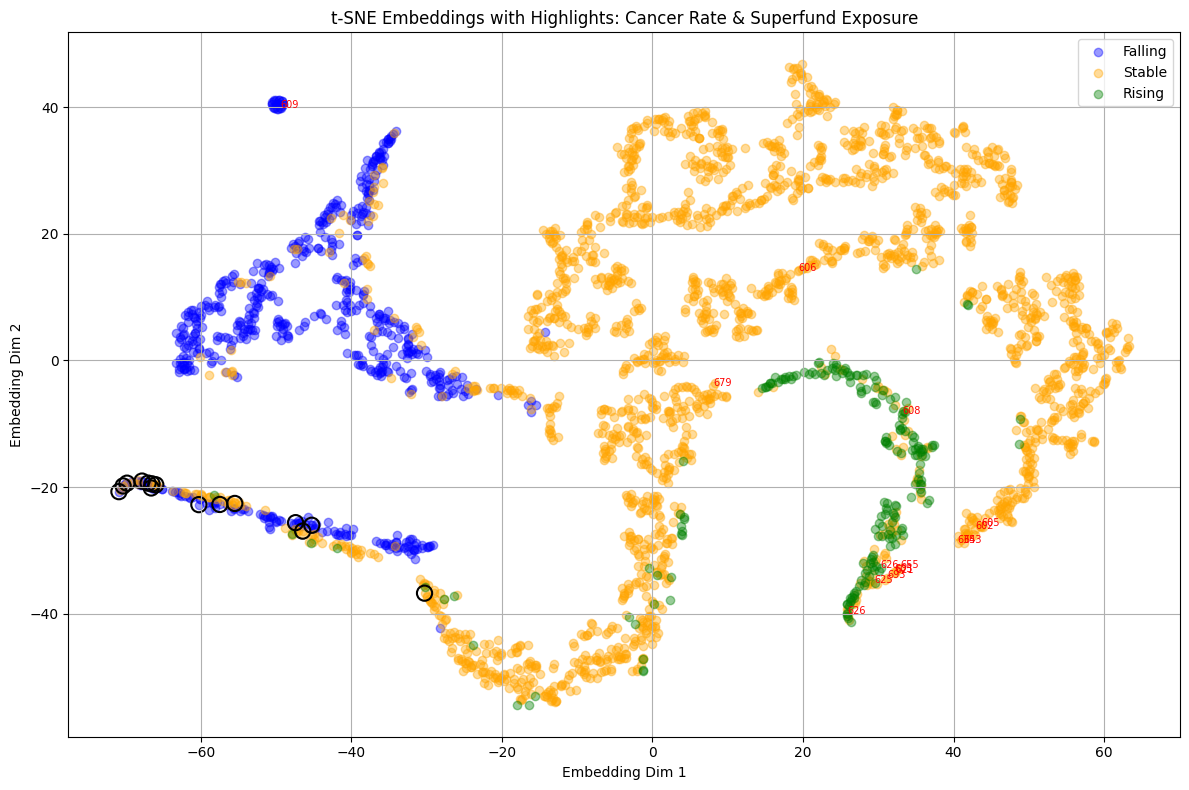

In [43]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reload datasets to get degree and cancer rate
county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")

# Merge node ID into feature set
county_data = pd.merge(county_node_map_df.rename(columns={"row_index": "county_node_id"}),
                       county_features_df, on="fips")

# Count superfund connections per county
from collections import Counter
degree_count = Counter([edge[0] for edge in edge_list])
county_data["degree"] = county_data["county_node_id"].map(degree_count).fillna(0).astype(int)

# Sort by exposure and cancer rate
top_exposed = county_data.sort_values("degree", ascending=False).head(15)
top_cancer = county_data.sort_values("cancer_rate", ascending=False).head(15)

# t-SNE for embedding visualization
with torch.no_grad():
    embeddings = model(data.x, data.edge_index).cpu()
county_embeddings = embeddings[:num_county_nodes]
county_labels = data.y[:num_county_nodes].cpu().numpy()
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(county_embeddings)

# Plot with highlights
plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green']
labels_map = {0: 'Falling', 1: 'Stable', 2: 'Rising'}

# Base scatter plot
for class_id in range(3):
    idx = county_labels == class_id
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
                c=colors[class_id], label=labels_map[class_id], alpha=0.4)

# Highlight top exposed counties
for _, row in top_exposed.iterrows():
    nid = row["county_node_id"]
    plt.scatter(embeddings_2d[nid, 0], embeddings_2d[nid, 1],
                edgecolor='black', facecolor='none', s=120, linewidths=1.5, label='Top Exposure' if _ == 0 else "")

# Annotate top cancer rate counties
for _, row in top_cancer.iterrows():
    nid = row["county_node_id"]
    plt.text(embeddings_2d[nid, 0], embeddings_2d[nid, 1],
             f"{int(row['cancer_rate'])}", fontsize=7, color='red')

plt.title("t-SNE Embeddings with Highlights: Cancer Rate & Superfund Exposure")
plt.xlabel("Embedding Dim 1")
plt.ylabel("Embedding Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Top Superfund-Exposed Counties:
These are outlined with black circles.

Their embeddings help explore whether counties with more environmental exposure form distinct patterns.

Top Cancer Rate Counties:
These have red number annotations showing their cancer incidence rate.

This reveals whether counties with extreme cancer rates are tightly grouped or scattered — helping assess model clustering fidelity.



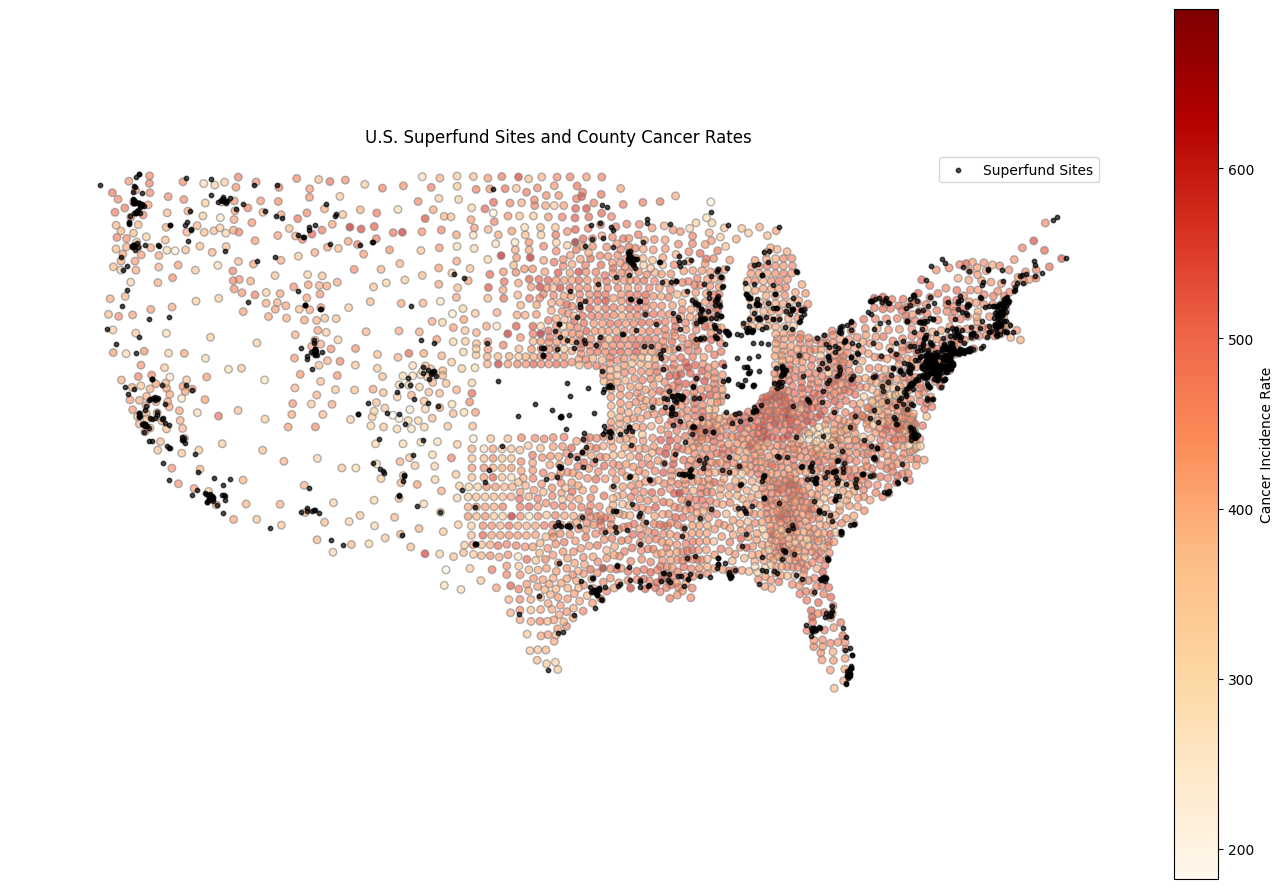

In [25]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Reload county and site datasets
county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")
fips_geo_df = pd.read_csv("/content/us_county_latlng.csv")

# Format FIPS
county_features_df["fips"] = county_features_df["fips"].astype(str).str.zfill(5)
county_node_map_df["fips"] = county_node_map_df["fips"].astype(str).str.zfill(5)
fips_geo_df["fips_code"] = fips_geo_df["fips_code"].astype(str).str.zfill(5)

# Merge for coordinates
fips_geo_df = fips_geo_df.rename(columns={"lat": "latitude", "lng": "longitude"})
county_data = pd.merge(county_node_map_df.rename(columns={"row_index": "county_node_id"}),
                       county_features_df, on="fips")
county_data = pd.merge(county_data, fips_geo_df[["fips_code", "latitude", "longitude"]],
                       left_on="fips", right_on="fips_code", how="left")

# County GeoDataFrame with cancer rates
county_gdf = gpd.GeoDataFrame(
    county_data,
    geometry=gpd.points_from_xy(county_data["longitude"], county_data["latitude"])
)
county_gdf.set_crs(epsg=4326, inplace=True)

# Load and prepare superfund site data
superfund_features_df = pd.read_csv("/content/DATA001_superfund_feature_dataframe_v1.csv")
superfund_node_map_df = pd.read_csv("/content/DATA001_superfund_node_id_map_v1.csv")

superfund_features_df["site_id"] = superfund_features_df["site_id"].astype(str)
superfund_node_map_df["site_id"] = superfund_node_map_df["site_id"].astype(str)
superfund_node_map_df["fips"] = superfund_node_map_df["fips"].astype(str).str.zfill(5)

# Merge lat/lon via site_id
superfund_data = pd.merge(superfund_node_map_df, superfund_features_df, on="site_id", how="left")
superfund_gdf = gpd.GeoDataFrame(
    superfund_data,
    geometry=gpd.points_from_xy(superfund_data["lon"], superfund_data["lat"])
)
superfund_gdf.set_crs(epsg=4326, inplace=True)

# Plot everything
fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# Plot counties colored by cancer rate
county_gdf.plot(
    ax=ax,
    column="cancer_rate",
    cmap="OrRd",
    legend=True,
    legend_kwds={"label": "Cancer Incidence Rate"},
    markersize=30,
    alpha=0.6,
    edgecolor="gray"
)

# Plot all Superfund sites
superfund_gdf.plot(ax=ax, color='black', markersize=10, alpha=0.7, label="Superfund Sites")

# Zoom to continental US
ax.set_xlim([-130, -65])
ax.set_ylim([23, 50])
ax.set_title("U.S. Superfund Sites and County Cancer Rates")
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


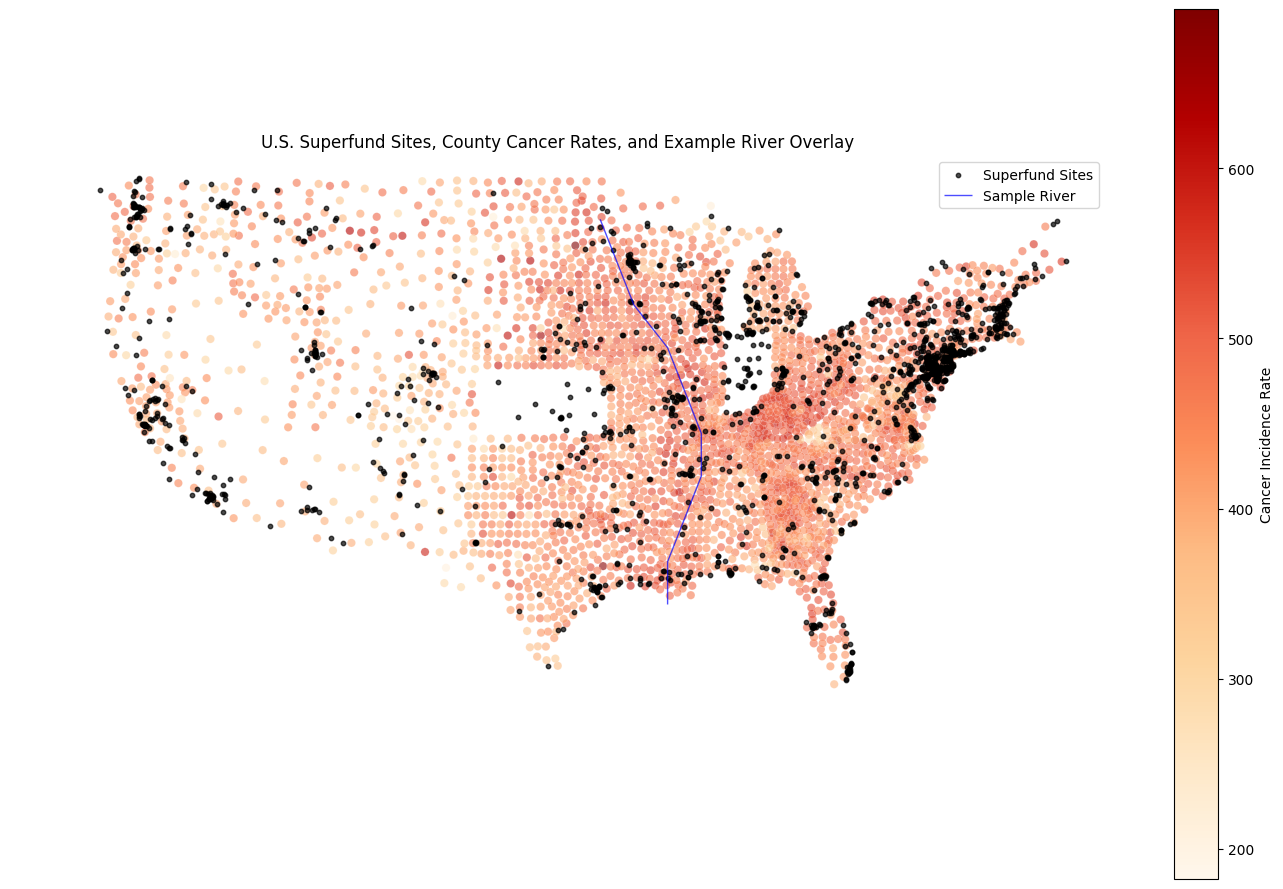

In [56]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# Synthetic river (Mississippi-like)
river_line = LineString([
    (-95, 47), (-94, 45), (-93, 43), (-91, 41),
    (-90, 39), (-89, 37), (-89, 35), (-90, 33),
    (-91, 31), (-91, 29)
])
rivers_gdf = gpd.GeoDataFrame(geometry=[river_line], crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# Cancer rate
county_gdf.plot(
    ax=ax,
    column="cancer_rate",
    cmap="OrRd",
    legend=True,
    legend_kwds={"label": "Cancer Incidence Rate"},
    alpha=0.6,
    edgecolor="white",
    linewidth=0.2
)

# Superfund sites
superfund_gdf.plot(ax=ax, color='black', markersize=10, alpha=0.7, label="Superfund Sites")

# Rivers (synthetic)
rivers_gdf.plot(ax=ax, color='blue', linewidth=1.0, alpha=0.7, label="Sample River")

# Bounding box for continental U.S.
ax.set_xlim([-130, -65])
ax.set_ylim([23, 50])
ax.set_title("U.S. Superfund Sites, County Cancer Rates, and Example River Overlay")
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


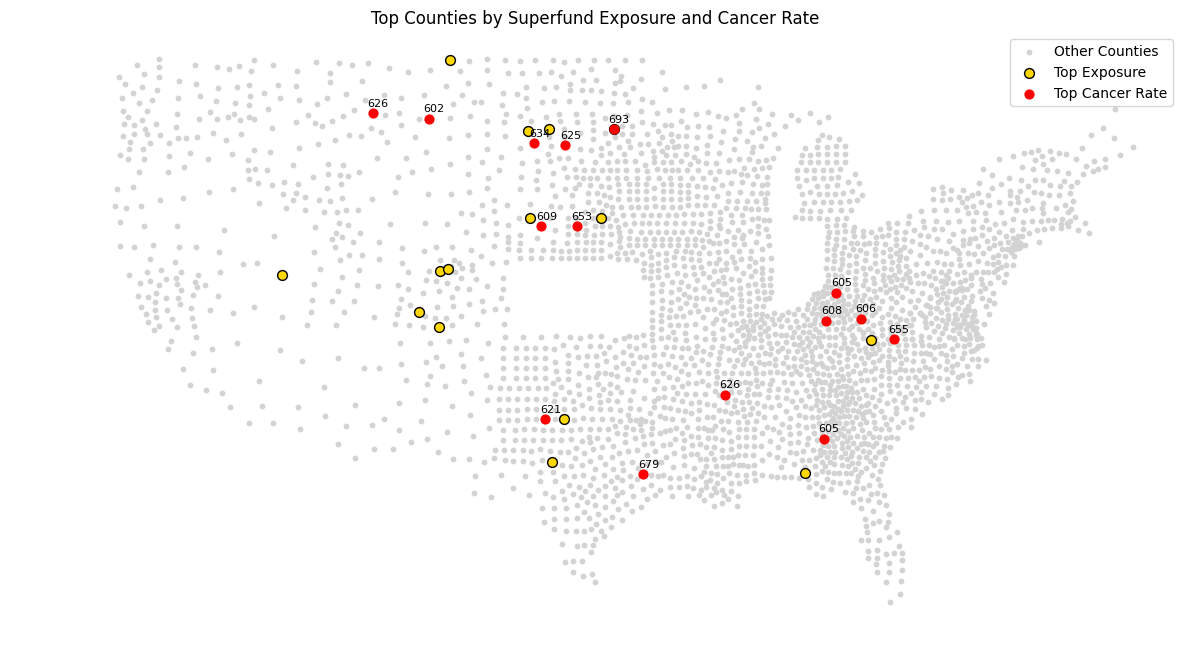

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter

# Load data
county_features_df = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_node_map_df = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")
fips_geo_df = pd.read_csv("/content/us_county_latlng.csv")  # Your downloaded lat/lon mapping file

# Standardize FIPS
county_features_df["fips"] = county_features_df["fips"].astype(str).str.zfill(5)
county_node_map_df["fips"] = county_node_map_df["fips"].astype(str).str.zfill(5)
fips_geo_df["fips_code"] = fips_geo_df["fips_code"].astype(str).str.zfill(5)

# Merge county info with node IDs
county_data = pd.merge(
    county_node_map_df.rename(columns={"row_index": "county_node_id"}),
    county_features_df,
    on="fips"
)

# Rename and merge coordinates
fips_geo_df = fips_geo_df.rename(columns={"lat": "latitude", "lng": "longitude"})
county_data = pd.merge(
    county_data,
    fips_geo_df[["fips_code", "latitude", "longitude"]],
    left_on="fips",
    right_on="fips_code",
    how="left"
)

# Simulate exposure score (replace with your real edge_list mapping if available)
degree_count = Counter()  # Example: Counter([edge[0] for edge in edge_list])
county_data["degree"] = county_data["county_node_id"].map(degree_count).fillna(0).astype(int)

# Extract top counties
top_exposed = county_data.sort_values("degree", ascending=False).head(15)
top_cancer = county_data.sort_values("cancer_rate", ascending=False).head(15)

# Convert to GeoDataFrame for mapping
gdf = gpd.GeoDataFrame(
    county_data,
    geometry=gpd.points_from_xy(county_data["longitude"], county_data["latitude"])
)
gdf.set_crs(epsg=4326, inplace=True)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
gdf.plot(ax=ax, markersize=10, color="lightgray", label="Other Counties")

# Highlight high exposure counties
highlight_exposed = gdf[gdf["county_node_id"].isin(top_exposed["county_node_id"])]
highlight_exposed.plot(ax=ax, color='gold', edgecolor='black', markersize=50, label="Top Exposure")

# Highlight and annotate top cancer counties
highlight_cancer = gdf[gdf["county_node_id"].isin(top_cancer["county_node_id"])]
highlight_cancer.plot(ax=ax, color='red', markersize=40, label="Top Cancer Rate")

for _, row in highlight_cancer.iterrows():
    ax.text(row.geometry.x + 0.3, row.geometry.y + 0.3, str(int(row["cancer_rate"])),
            fontsize=8, color='black', ha='center')

# Finalize
ax.set_title("Top Counties by Superfund Exposure and Cancer Rate")
ax.set_axis_off()
ax.legend()

# Focus only on continental U.S.
ax.set_xlim([-130, -65])
ax.set_ylim([23, 50])

plt.tight_layout()
plt.show()



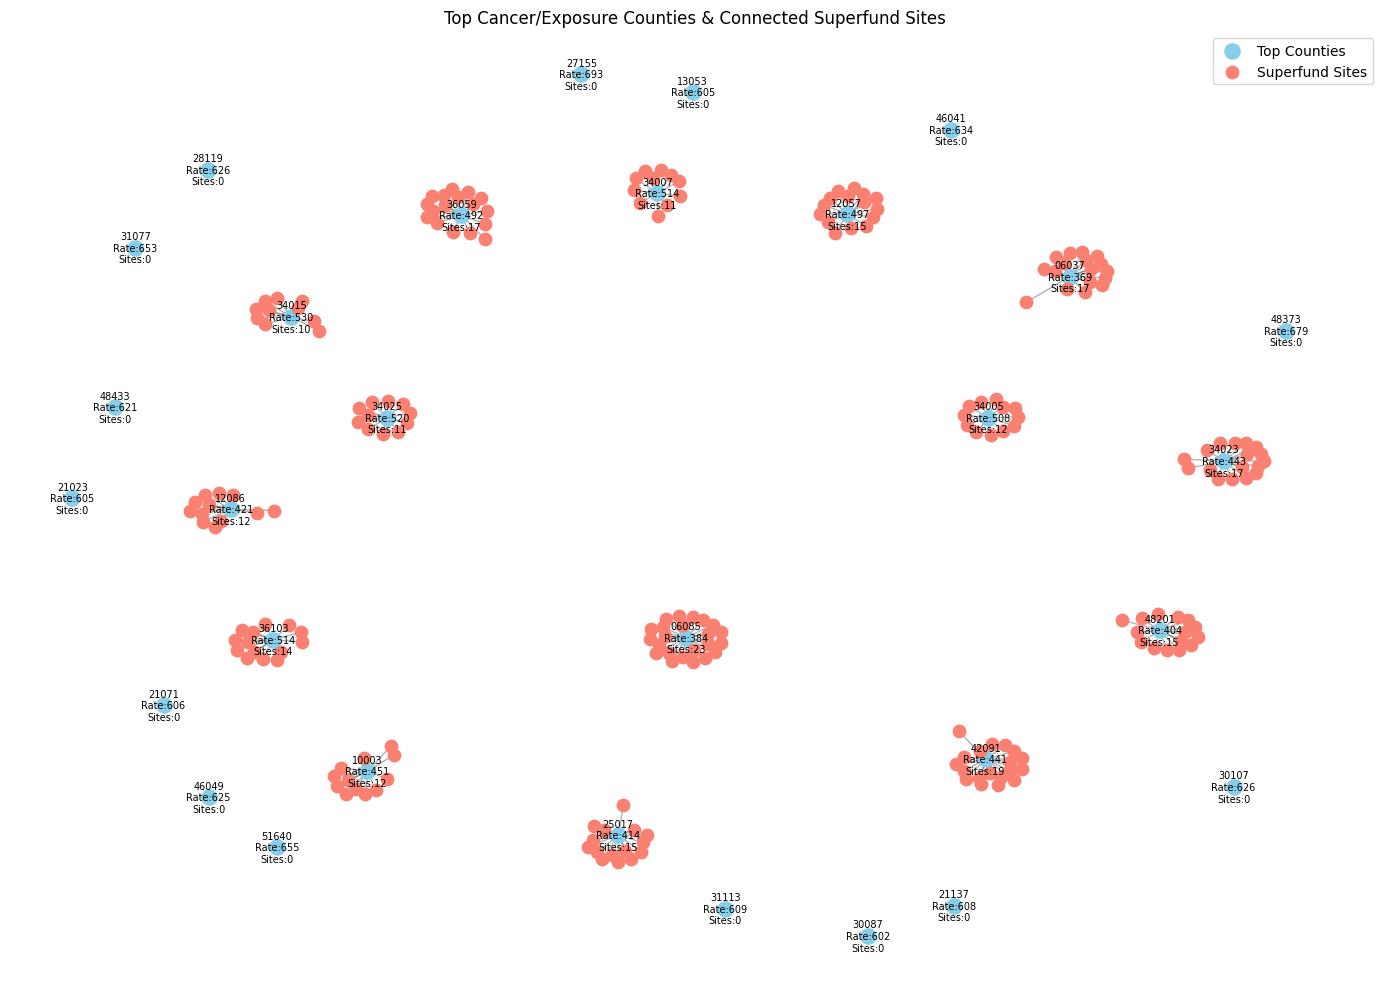

In [52]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Load data
county_data = pd.read_csv("/content/DATA002_county_feature_dataframe_v1.csv")
county_nodes = pd.read_csv("/content/DATA002_county_node_id_map_v1.csv")
superfund_nodes = pd.read_csv("/content/DATA001_superfund_node_id_map_v1.csv")

# Clean FIPS for merge
county_data["fips"] = county_data["fips"].astype(str).str.zfill(5)
county_nodes["fips"] = county_nodes["fips"].astype(str).str.zfill(5)
superfund_nodes["fips"] = superfund_nodes["fips"].astype(str).str.zfill(5)

# Merge node IDs
county_nodes.rename(columns={"row_index": "county_node_id"}, inplace=True)
superfund_nodes.rename(columns={"row_index": "superfund_node_id"}, inplace=True)

# Create edge list by matching FIPS
edges_df = pd.merge(
    superfund_nodes[["superfund_node_id", "fips"]],
    county_nodes[["county_node_id", "fips"]],
    on="fips"
)

# Offset superfund node IDs to avoid collisions
offset = county_nodes["county_node_id"].max() + 1
edges_df["superfund_node_id"] += offset

# Merge to include cancer rate
county_all = pd.merge(county_nodes, county_data, on="fips", how="left")

# Compute degrees (connections)
degree_count = Counter(edges_df["county_node_id"])
county_all["degree"] = county_all["county_node_id"].map(degree_count).fillna(0).astype(int)

# Top 15 counties by cancer rate or exposure degree
top_cancer = county_all.sort_values("cancer_rate", ascending=False).head(15)
top_exposed = county_all.sort_values("degree", ascending=False).head(15)
selected_ids = set(top_cancer["county_node_id"]) | set(top_exposed["county_node_id"])

# Filter edges to include only those related to selected counties
filtered_edges = edges_df[edges_df["county_node_id"].isin(selected_ids)]

# Build graph
G = nx.Graph()
for node_id in selected_ids:
    G.add_node(node_id, node_type='county')

for _, row in filtered_edges.iterrows():
    county_id = row["county_node_id"]
    superfund_id = row["superfund_node_id"]
    G.add_node(superfund_id, node_type='superfund')
    G.add_edge(county_id, superfund_id)

# Assign layout
pos = nx.spring_layout(G, seed=42)

# Label county nodes
county_labels = {}
for node_id in selected_ids:
    row = county_all[county_all["county_node_id"] == node_id].iloc[0]
    label = f"{row['fips']}\nRate:{int(row['cancer_rate'])}\nSites:{int(row['degree'])}"
    county_labels[node_id] = label

# Draw graph
county_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'county']
superfund_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'superfund']

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, nodelist=county_nodes, node_color='skyblue', node_size=120, label='Top Counties')
nx.draw_networkx_nodes(G, pos, nodelist=superfund_nodes, node_color='salmon', node_size=80, label='Superfund Sites')
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, labels=county_labels, font_size=7)

plt.title("Top Cancer/Exposure Counties & Connected Superfund Sites")
plt.axis('off')
plt.legend()
plt.tight_layout()
plt.show()


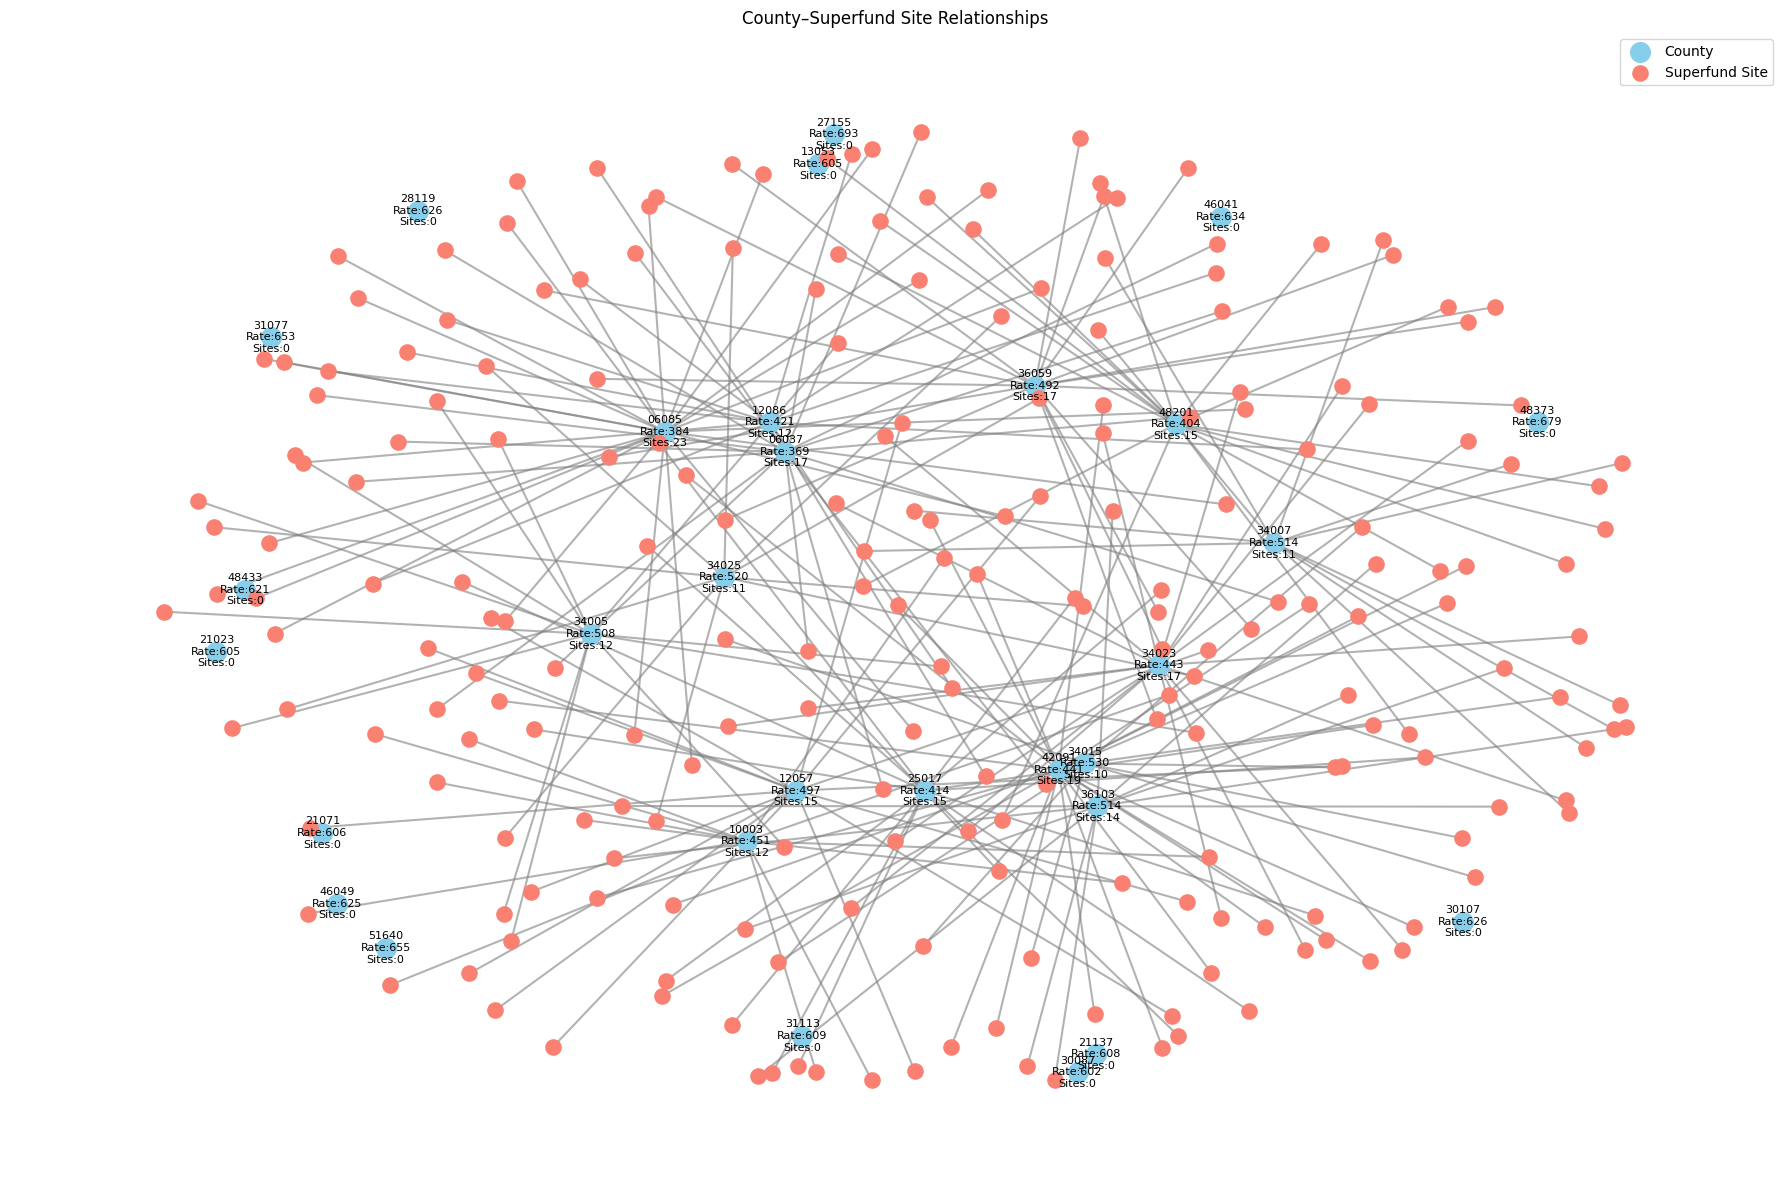

In [53]:
# Use a layout that spreads out nodes more clearly
pos = nx.spring_layout(G, k=0.4, seed=42)

plt.figure(figsize=(18, 12))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=county_nodes, node_color='skyblue', node_size=200, label='County')
nx.draw_networkx_nodes(G, pos, nodelist=superfund_nodes, node_color='salmon', node_size=120, label='Superfund Site')

# Draw edges with more visibility
nx.draw_networkx_edges(G, pos, width=1.5, edge_color='gray', alpha=0.6)

# County labels (FIPS + cancer + degree)
nx.draw_networkx_labels(G, pos, labels=county_labels, font_size=8, font_color='black')

# Optional: edge labels (Superfund site ID or just relationship)
# edge_labels = {(u, v): 'Connected' for u, v in G.edges()}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title("County–Superfund Site Relationships")
plt.axis('off')
plt.legend()
plt.tight_layout()
plt.show()


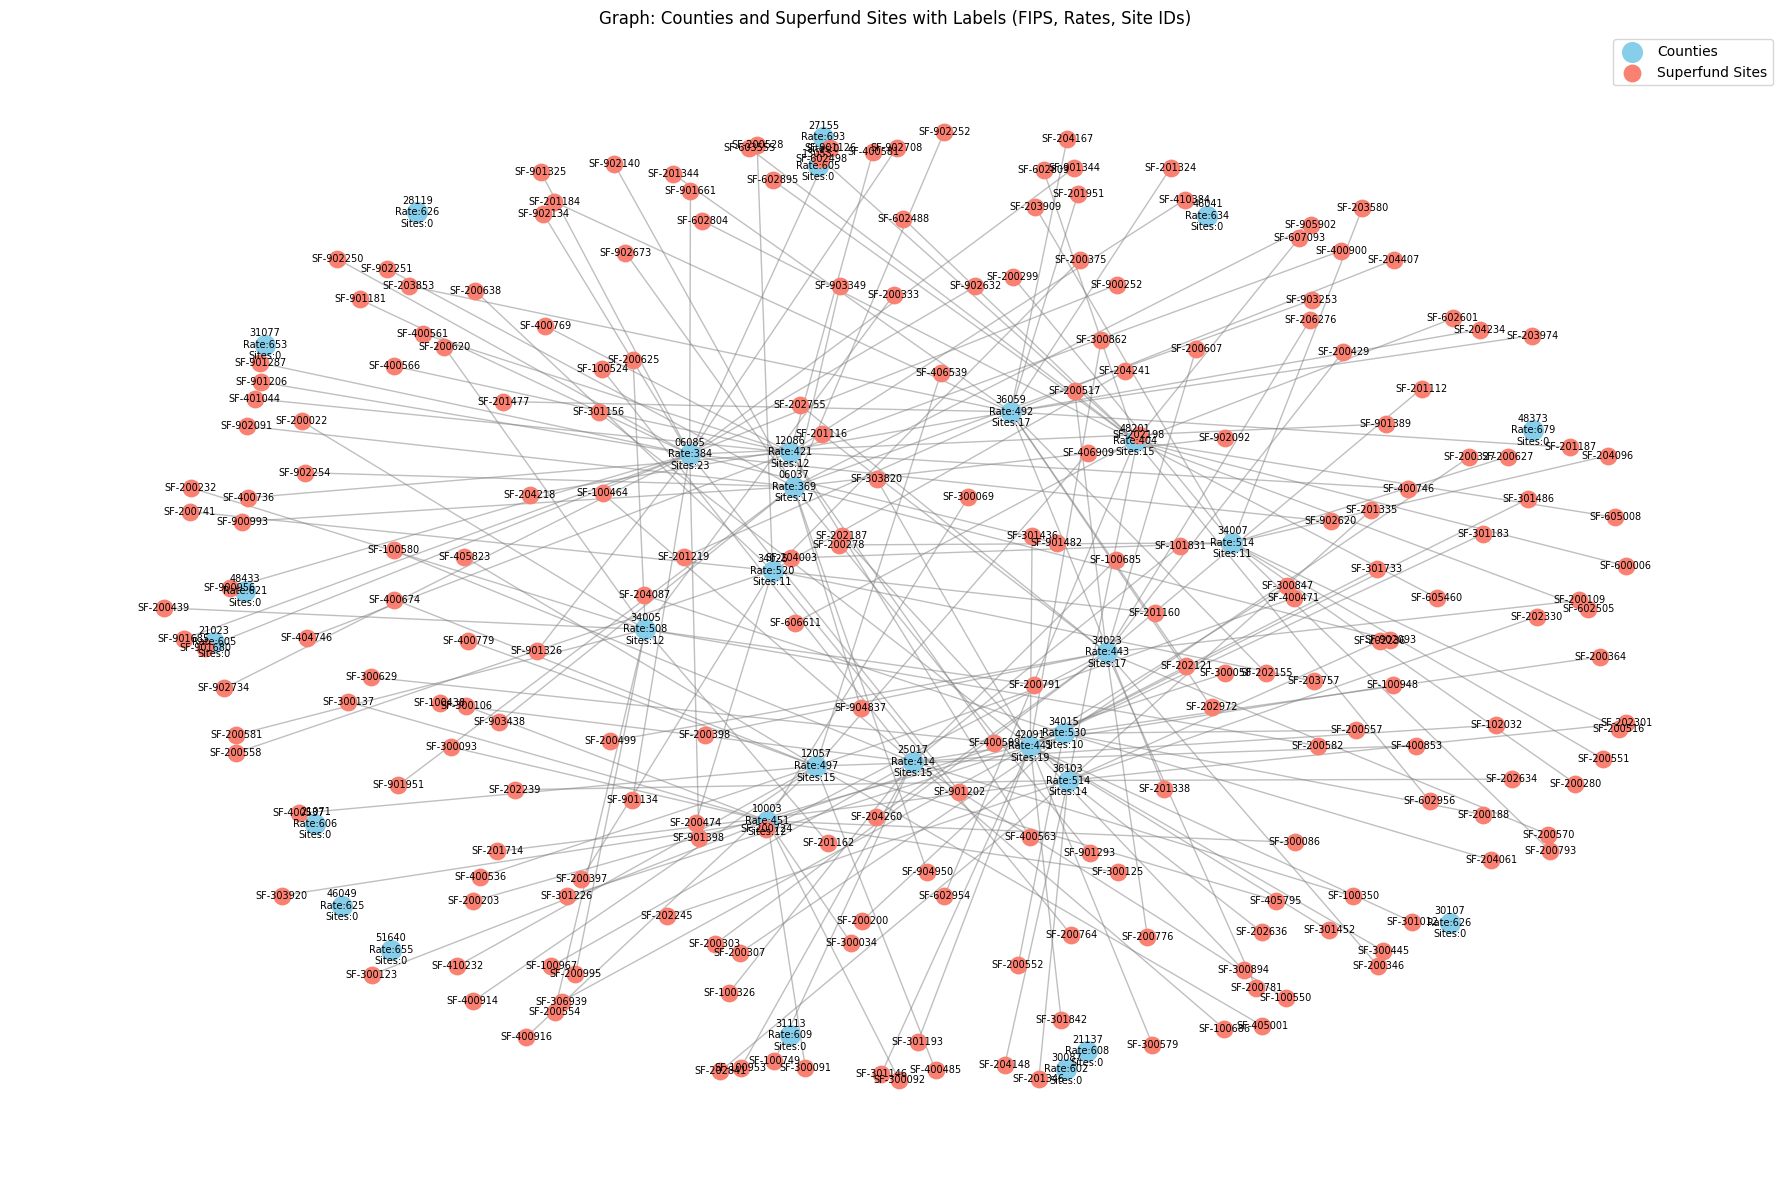

In [55]:
#  Recompute offset using county_all
offset = county_all["county_node_id"].max() + 1

# Make a copy to avoid overwriting the original
sf_labeled_df = superfund_node_map_df.copy()
sf_labeled_df["superfund_node_id_offset"] = sf_labeled_df["row_index"] + offset

# Map node_id → site_id
superfund_name_map = sf_labeled_df.set_index("superfund_node_id_offset")["site_id"].to_dict()

# Combine labels: county and superfund
all_labels = {}

# County labels: FIPS, rate, degree
for node_id in selected_county_ids:
    row = county_all[county_all["county_node_id"] == node_id].iloc[0]
    all_labels[node_id] = f"{row['fips']}\nRate:{int(row['cancer_rate'])}\nSites:{int(row['degree'])}"

# Superfund labels: site_id
for node_id in G.nodes:
    if node_id in superfund_name_map:
        all_labels[node_id] = f"SF-{superfund_name_map[node_id]}"

# Plot the graph
pos = nx.spring_layout(G, k=0.45, seed=42)
plt.figure(figsize=(18, 12))

nx.draw_networkx_nodes(G, pos, nodelist=county_nodes, node_color='skyblue', node_size=200, label='Counties')
nx.draw_networkx_nodes(G, pos, nodelist=superfund_nodes, node_color='salmon', node_size=140, label='Superfund Sites')
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, labels=all_labels, font_size=7)

plt.title("Graph: Counties and Superfund Sites with Labels (FIPS, Rates, Site IDs)")
plt.axis('off')
plt.legend()
plt.tight_layout()
plt.show()
